In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## RGB 채널별 시각화

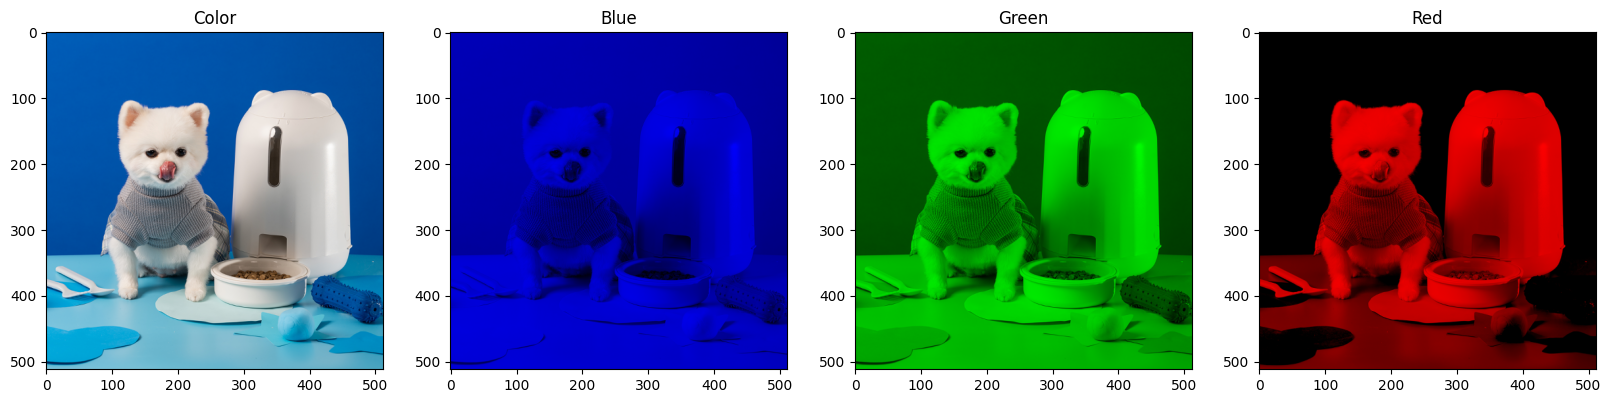

In [11]:
# 이미지 불러오기
dog_color = cv2.imread('dog_color.png',3)

# 채널 분리
b, g, r = cv2.split(dog_color)
z = np.zeros_like(b)

# 한 채널을 제외하고 전부 0으로 채움
blue  = cv2.merge([z, z, b])
green = cv2.merge([z, g, z])
red   = cv2.merge([r, z, z])

# 시각화
plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.title('Color')
plt.imshow(cv2.cvtColor(dog_color, cv2.COLOR_BGR2RGB))

plt.subplot(1,4,2)
plt.title('Blue')
plt.imshow(blue)

plt.subplot(1,4,3)
plt.title('Green')
plt.imshow(green)

plt.subplot(1,4,4)
plt.title('Red')
plt.imshow(red)

plt.show()

## 이미지 정규화 후 시각화

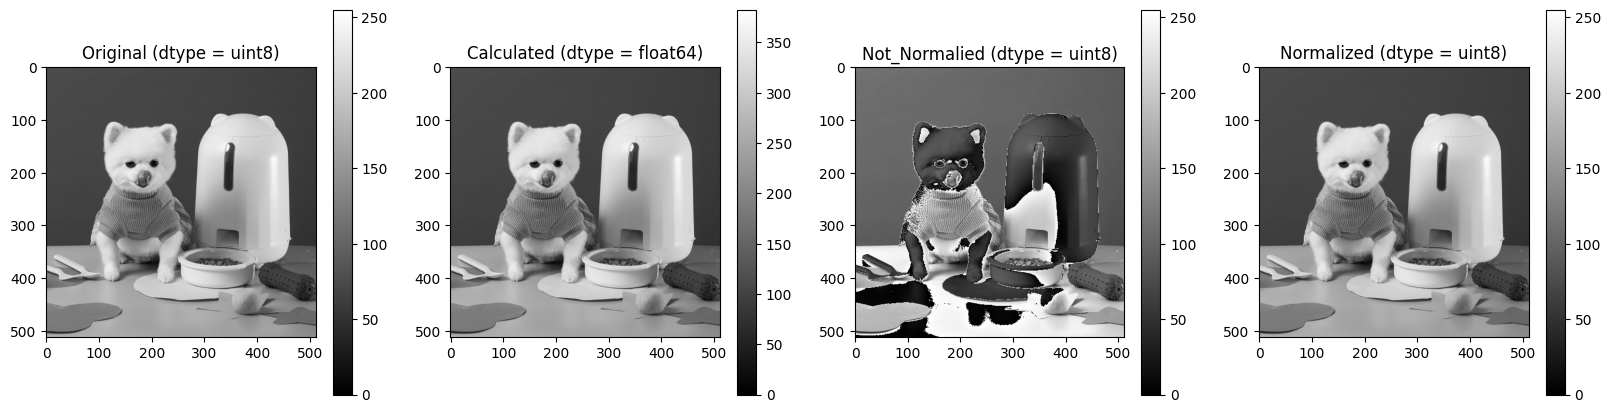

In [23]:
# 컬러를 흑백으로 전환
dog_gray = cv2.cvtColor(dog_color, cv2.COLOR_BGR2GRAY)
# 수치적 계산
dog_new = dog_gray * 1.5

# Colorbar의 범위와 데이터 타입에 주목
plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.title(f'Original (dtype = {dog_gray.dtype})')
plt.imshow(dog_gray, cmap='gray')
plt.colorbar()

plt.subplot(1,4,2)
plt.title(f'Calculated (dtype = {dog_new.dtype})')
plt.imshow(dog_new, cmap='gray')
plt.colorbar()

plt.subplot(1,4,3)
dog_new_uint = dog_new.astype(np.uint8)
plt.title(f'Not_Normalied (dtype = {dog_new_uint.dtype})')
plt.imshow(dog_new_uint, cmap='gray')
plt.colorbar()

plt.subplot(1,4,4)
dog_new_Normalized = cv2.normalize(dog_new, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.title(f'Normalized (dtype = {dog_new_Normalized.dtype})')
plt.imshow(dog_new_Normalized, cmap='gray')
plt.colorbar()

plt.show()

## Sobel Filter를 적용하여 시각화

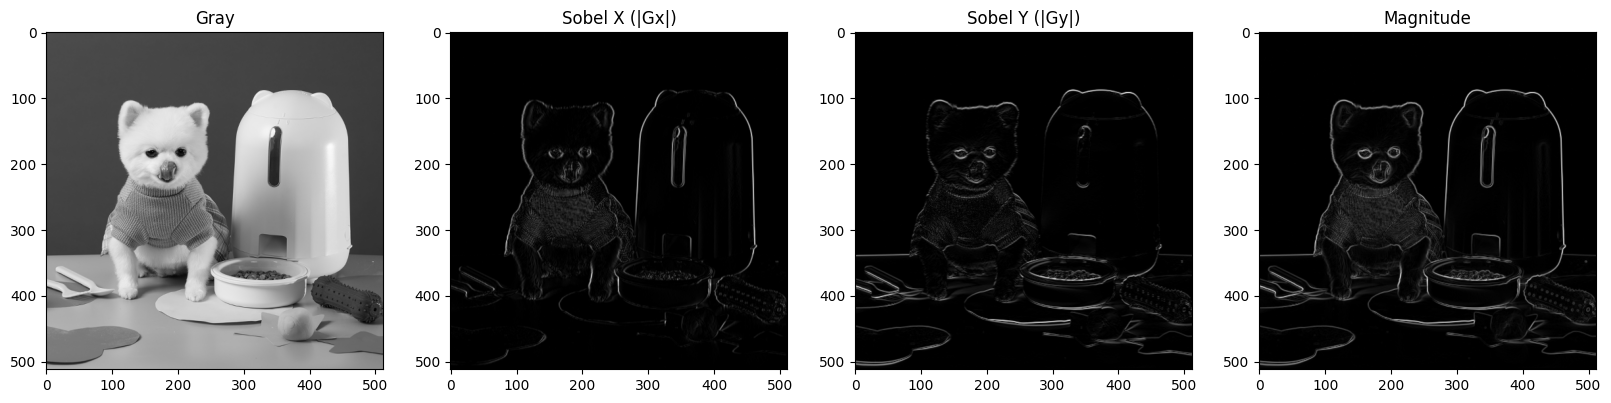

In [32]:
# Sobel kernel 정의
sobel_x = np.array([[-1, 0,  1],
                    [-2, 0,  2],
                    [-1, 0,  1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)

# Convolution 연산 수행
gx = cv2.filter2D(dog_gray, ddepth=cv2.CV_32F, kernel=sobel_x)
gy = cv2.filter2D(dog_gray, ddepth=cv2.CV_32F, kernel=sobel_y)

# Gradient magnitude 계산
mag = np.sqrt(gx**2 + gy**2)

# 시각화를 위해 정규화
gx_vis  = np.abs(gx)
gy_vis  = np.abs(gy)
mag_vis = mag

# 시각화
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.title("Gray")
plt.imshow(dog_gray, cmap="gray")

plt.subplot(1, 4, 2)
plt.title("Sobel X (|Gx|)")
plt.imshow(gx_vis, cmap="gray")

plt.subplot(1, 4, 3)
plt.title("Sobel Y (|Gy|)")
plt.imshow(gy_vis, cmap="gray")

plt.subplot(1, 4, 4)
plt.title("Magnitude")
plt.imshow(mag_vis, cmap="gray")

plt.show()

# Log 연산을 통해 대조 강화 시각화

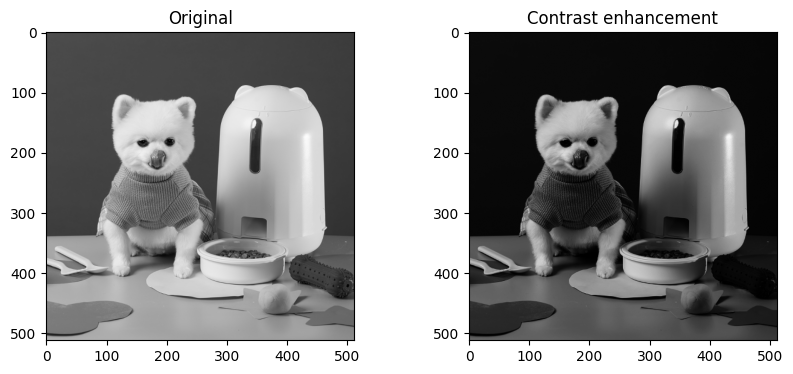

In [40]:
# Log 연산
dog_log = dog_gray**2.5

# 시각화
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(dog_gray, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Contrast enhancement")
plt.imshow(dog_log, cmap="gray")

plt.show()

## 모아레 노이즈가 포함된 이미지 생성

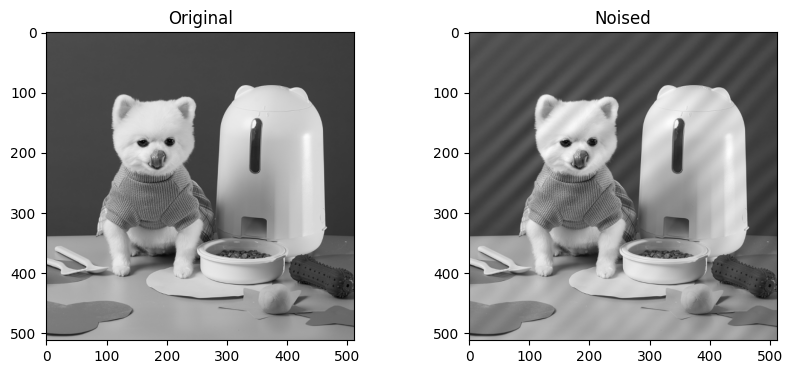

In [75]:
# 푸리에 변환
F_dog = np.fft.rfft2(dog_gray)
# 특정 주기의 노이즈 추가
F_dog[10:13,10:13] *= 5
# 역변환
dog_noised = np.fft.irfft2(F_dog)

# 시각화
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(dog_gray, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Noised")
plt.imshow(dog_noised, cmap="gray")

plt.show()

## Bitwise 연산을 통한 합성

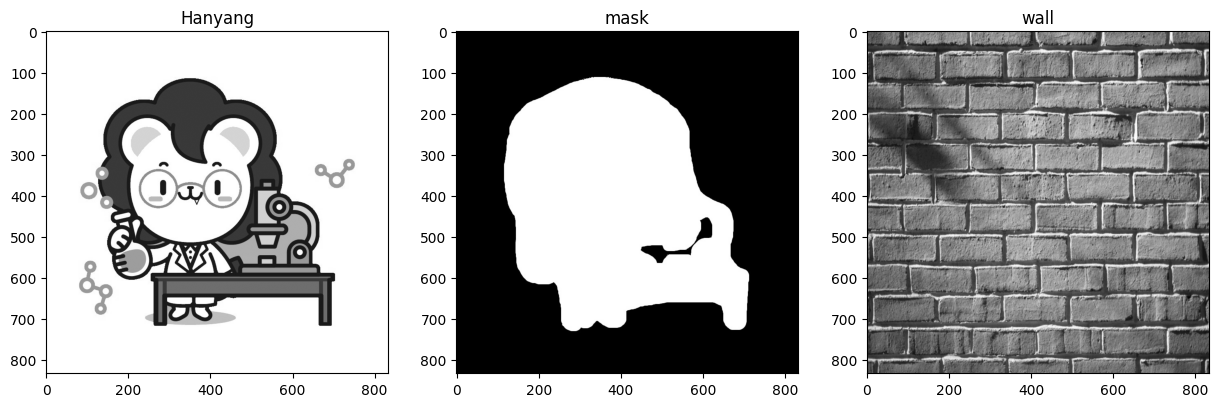

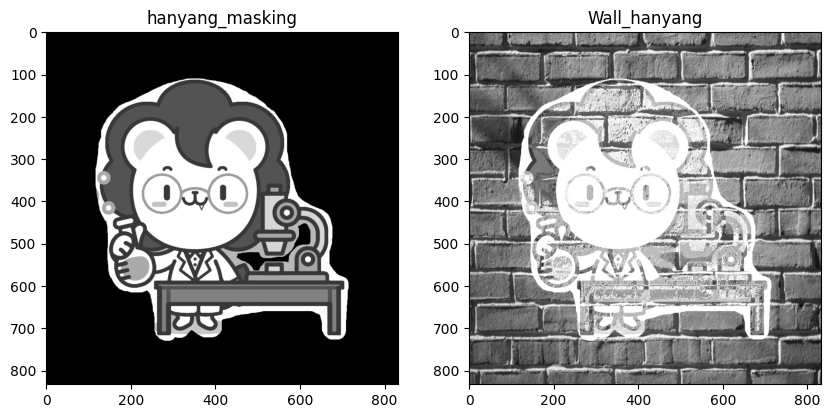

In [90]:
# 각 이미지 불러오기 및 크기 조정
hanyang = cv2.imread('./hanyang.jpg',0)
mask = cv2.imread('./hanyang_mask.jpg',0)
wall = cv2.imread('./wall.png',0)
wall = cv2.resize(wall,(833,833))

# 시각화
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title('Hanyang')
plt.imshow(hanyang, cmap='gray')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title('mask')

plt.subplot(1,3,3)
plt.imshow(wall, cmap='gray')
plt.title('wall')

plt.show()

# 이미지 합성
hanyang_masking = cv2.bitwise_and(hanyang, mask)
wall_hanyang = cv2.bitwise_or(wall,hanyang_masking)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(hanyang_masking, cmap='gray')
plt.title('hanyang_masking')

plt.subplot(1,2,2)
plt.imshow(wall_hanyang, cmap='gray')
plt.title('Wall_hanyang')

plt.show()